In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_train = pd.read_csv("AppML_InitialProject_train.csv")
df_train = df_train.drop(columns=["p_Truth_Energy"])
df_test = pd. read_csv("AppML_InitialProject_test_classification.csv")

df_train.shape

(180000, 141)

In [3]:
df_train

,averageInteractionsPerCrossing,p_Rhad1,p_Rhad,p_f3,p_weta2,p_Rphi,p_Reta,p_Eratio,p_f1,p_TRTPID,...,pX_E7x11_Lr1,pX_E7x11_Lr2,pX_E7x11_Lr3,pX_E7x7_Lr0,pX_E7x7_Lr1,p_pt_track,p_eta,p_phi,p_charge,p_Truth_isElectron
0,55.50,-0.002390,-0.003614,0.000744,0.010088,0.947685,0.983722,0.969448,0.355275,-0.030026,...,16208.0300,27951.328,473.046360,1415.2955,16208.0300,38339.8750,0.725108,2.511338,-1.0,1
1,33.50,-0.009279,-0.010666,0.003784,0.011625,0.922366,0.955934,0.918366,0.397633,0.335419,...,28639.7420,34642.820,86.462740,11456.5240,28639.7420,26470.8900,1.566765,-0.593568,-1.0,1
2,35.50,0.002806,0.013643,0.025505,0.010330,0.969845,0.945576,0.921568,0.077971,0.517517,...,8061.6840,88892.890,2173.160200,0.0000,8061.6840,32989.9570,1.926261,2.497809,-1.0,1
3,40.49,-0.001910,0.000044,0.000176,0.010323,0.923816,0.888029,0.000000,0.000000,0.133801,...,27257.8890,39768.450,102.033676,35418.3050,27154.4340,86615.2340,1.510641,2.441266,-1.0,1
4,52.50,0.013779,-0.002106,0.010156,0.010096,0.899883,0.717177,0.782584,0.253658,-0.044038,...,6206.0938,15531.818,277.199130,1242.5723,6206.0938,17362.5060,-0.113342,3.003595,-1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,48.50,0.664485,0.785885,0.030614,0.013458,0.706411,0.803551,0.176808,0.310948,0.090996,...,9420.7740,19028.691,1456.618000,2519.9902,9452.5410,21610.8260,-0.333357,2.638398,1.0,0
179996,45.49,0.626207,0.890136,0.002500,0.011333,0.933887,0.870006,0.887657,0.288254,-0.153530,...,7939.0913,14750.185,995.310060,3643.7200,7939.0913,19252.5310,-1.206471,-1.202972,1.0,0
179997,49.50,0.068849,0.099816,0.017091,0.013220,0.777033,0.898677,0.127255,0.378862,-0.000000,...,22392.7870,48182.340,697.059200,0.0000,22392.7870,3583.9360,2.352615,-2.420230,-1.0,0
179998,39.49,0.688895,1.168897,0.009258,0.012657,0.503309,0.734173,0.092843,0.412541,-0.320695,...,20544.4140,26506.123,976.097800,8783.8370,20544.4140,7410.3380,-1.650526,-1.739836,-1.0,0


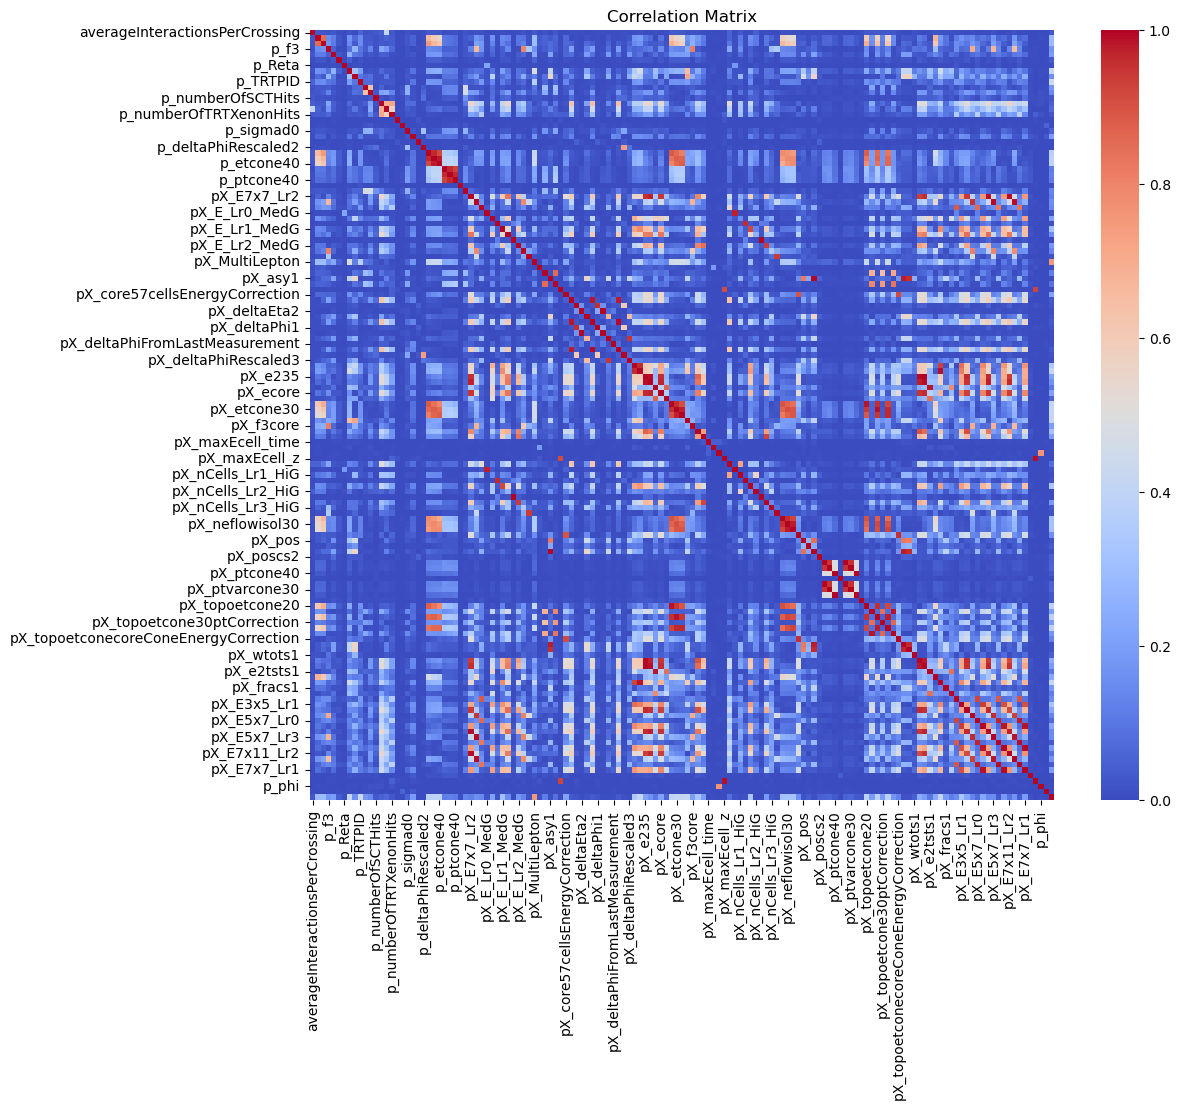

In [4]:
corr = df_train.corr().abs()

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0
)


plt.title("Correlation Matrix")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import shap
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler

In [6]:
X = df_train.drop(columns=["p_Truth_isElectron"])
y = df_train["p_Truth_isElectron"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [7]:
# Train a BDT on all the feautures
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

# Find the feauture importance
importance = model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
})

feat_importance = feat_importance.sort_values(
    by="importance",
    ascending=False
)

print(feat_importance.head(15))
# Extract the 15 most important features
top15 = feat_importance.head(15)["feature"].tolist()

X_train_top = X_train[top15]
X_valid_top = X_valid[top15]

/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


                                   feature  importance
42                          pX_MultiLepton    0.433135
22                              p_etcone20    0.155370
10            p_numberOfInnermostPixelHits    0.084854
23                              p_etcone30    0.030117
18                               p_sigmad0    0.014102
111  pX_topoetconecoreConeEnergyCorrection    0.012141
9                                 p_TRTPID    0.012068
28                                p_ptPU30    0.012060
92   pX_neflowisolcoreConeEnergyCorrection    0.010905
7                                 p_Eratio    0.010842
20                             p_deltaEta1    0.008031
2                                   p_Rhad    0.007641
44                        pX_ambiguityType    0.007594
46                               pX_author    0.007105
50                            pX_deltaEta1    0.006942


In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_top)
X_val_scaled = scaler.transform(X_valid_top)

In [10]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(15,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['AUC']
)
print('--------- TRAINING ---------')
history = model.fit(x = np.array(X_train_scaled), y = np.array(y_train), validation_data=(np.array(X_val_scaled), np.array(y_valid)), epochs = 7) 

--------- TRAINING ---------
Epoch 1/7


/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3938/3938 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - AUC: 0.9649 - loss: 0.1774 - val_AUC: 0.9811 - val_loss: 0.1360
Epoch 2/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.9777 - loss: 0.1424 - val_AUC: 0.9843 - val_loss: 0.1217
Epoch 3/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.9796 - loss: 0.1347 - val_AUC: 0.9846 - val_loss: 0.1194
Epoch 4/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.9805 - loss: 0.1323 - val_AUC: 0.9837 - val_loss: 0.1381
Epoch 5/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - AUC: 0.9816 - loss: 0.1289 - val_AUC: 0.9861 - val_loss: 0.1139
Epoch 6/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - AUC: 0.9827 - loss: 0.1256 - val_AUC: 0.9828 - val_loss: 0.1520
Epoch 7/7
3938/3938 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - AUC: 0.9833 - loss: 0.1235 - val_AUC: 0.9868 - val_loss: 0.1132


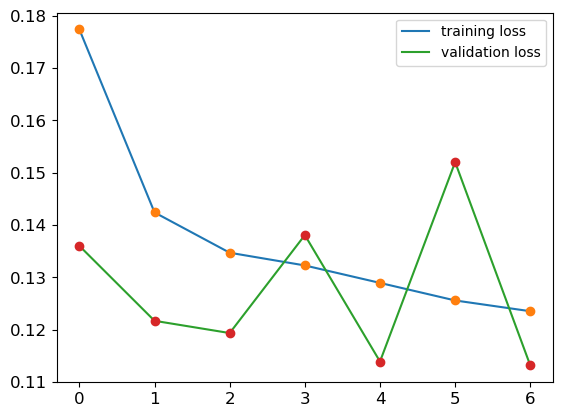

In [11]:
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

fig =  plt.figure()
plt.plot(training_loss,label = 'training loss')
plt.plot(training_loss,'o')
plt.plot(validation_loss, label = 'validation loss')
plt.plot(validation_loss, 'o')
plt.legend()
plt.xticks(size = 12)
plt.yticks(size = 12)
plt.show()

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step


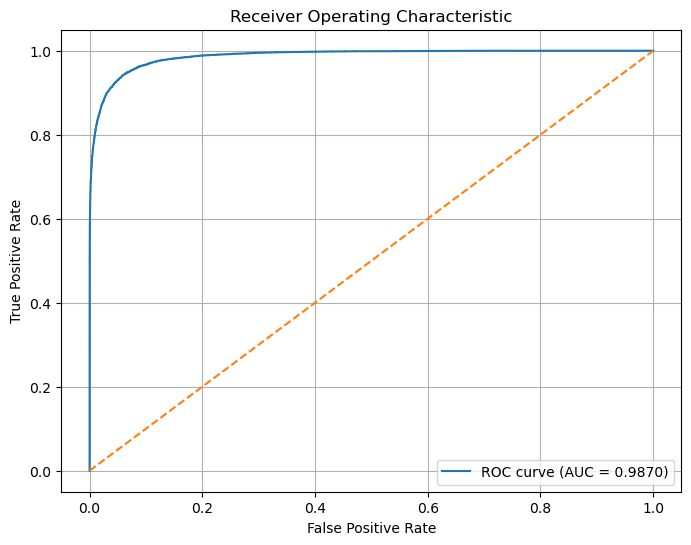

In [12]:
# Predict probabilities
y_pred_prob = model.predict(X_val_scaled).ravel()

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')

plt.grid(True)

plt.show()

In [13]:
X_unlabeled_top = df_test[top15]

X_unlabeled_scaled = scaler.transform(X_unlabeled_top)

y_pred = model.predict(np.array(X_unlabeled_scaled))

print(y_pred[:10])

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step
[[0.9840643 ]
 [0.78513426]
 [0.11061534]
 [0.98493874]
 [0.66428256]
 [0.9923478 ]
 [0.96422213]
 [0.01765974]
 [0.94400024]
 [0.9955104 ]]


In [15]:
pred_df = X_unlabeled_top.copy()
pred_df['prediction'] = y_pred.flatten()


pred_df

,pX_MultiLepton,p_etcone20,p_numberOfInnermostPixelHits,p_etcone30,p_sigmad0,pX_topoetconecoreConeEnergyCorrection,p_TRTPID,p_ptPU30,pX_neflowisolcoreConeEnergyCorrection,p_Eratio,p_deltaEta1,p_Rhad,pX_ambiguityType,pX_author,pX_deltaEta1,prediction
0,1,0.062348,1,0.130220,0.012406,35753.570,0.118954,0.000000e+00,35753.566,0.924800,-0.001190,0.005931,0,1,-0.001190,0.984064
1,0,0.714565,0,1.215868,0.057154,23236.273,0.334848,1.427523e-04,20907.700,0.469015,-0.006406,0.154005,0,1,-0.006406,0.785134
2,0,0.469450,1,0.587822,0.062318,34410.105,0.168309,0.000000e+00,34410.105,0.453793,0.063462,0.214753,3,16,0.063462,0.110615
3,1,0.157164,1,0.162666,0.015904,36392.780,0.276550,3.468879e-01,36392.780,0.964431,0.001025,0.016198,0,1,0.001025,0.984939
4,0,-0.015953,0,-0.123927,2.668945,23719.148,0.400937,6.129685e-07,23719.148,0.933000,0.004196,-0.041287,4,16,0.004196,0.664283
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,0,0.802182,1,1.211171,0.033359,31309.879,-0.048342,1.432046e-04,31309.880,0.867622,0.050317,0.045476,0,1,0.050317,0.008258
59996,0,0.607455,1,3.167290,0.160340,14066.244,-0.327549,1.370163e-03,13302.504,0.332477,0.081185,0.154278,2,16,0.081185,0.006343
59997,0,1.004287,1,2.414493,0.028997,22460.896,0.149209,3.081606e-05,12633.730,0.817691,0.016788,0.172812,0,1,0.016788,0.047393
59998,0,0.894341,1,0.997297,0.017254,42330.137,-0.194332,3.616134e-05,38515.965,0.342194,0.005099,0.306468,0,1,0.005099,0.001783


In [16]:
pred_df = pd.DataFrame({
    'prediction': y_pred.flatten()
})

# Add binary column based on threshold 0.5
pred_df['class'] = (pred_df['prediction'] > 0.5).astype(int)

print(pred_df.head())

   prediction  class
0    0.984064      1
1    0.785134      1
2    0.110615      0
3    0.984939      1
4    0.664283      1


In [17]:
pred_df.to_csv("classification_NN_rough.csv", index = False)